In [ ]:
!pip install wfdb torch numpy pandas matplotlib scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [ ]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
records = wfdb.get_record_list('mitdb')

signals = []
labels = []

window_size = 128

label_map = {
    'N': 0,
    'V': 1,
    'A': 2
}

for record_name in records:

    record = wfdb.rdrecord(f'mitdb/{record_name}')
    annotation = wfdb.rdann(f'mitdb/{record_name}', 'atr')

    signal = record.p_signal[:, 0]

    for i, sample in enumerate(annotation.sample):

        symbol = annotation.symbol[i]

        if symbol in label_map:

            if sample-window_size >= 0 and sample+window_size < len(signal):

                beat = signal[sample-window_size : sample+window_size]

                signals.append(beat)

                labels.append(label_map[symbol])

In [ ]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)
print(y.shape)

(84696, 256)
(84696,)


In [ ]:
X = (X - np.mean(X, axis=1, keepdims=True)) / \
    (np.std(X, axis=1, keepdims=True) + 1e-8)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return x, y

In [ ]:
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, d_model, nhead):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            batch_first=True
        )

    def forward(self, x):

        attn_output, attn_weights = self.attention(
            x,
            x,
            x,
            need_weights=True
        )

        return attn_output, attn_weights

In [ ]:
class CNNTransformer(nn.Module):

    def __init__(
        self,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_classes=3
    ):

        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                d_model,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.attention_block = AttentionBlock(
            d_model=d_model,
            nhead=nhead

        )


        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # (batch, seq)
        x = x.unsqueeze(1)

        # CNN
        x = self.cnn(x)

        # (batch, channels, seq)
        x = x.permute(0, 2, 1)

        # attn
        x, attn_weights = self.attention_block(x)

        # Global pooling
        x = x.mean(dim=1)

        return self.classifier(x), attn_weights

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNTransformer().to(device)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0

    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs, _ = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        correct += (predicted == y_batch).sum().item()

        total += y_batch.size(0)

    # Epoch accuracy
    accuracy = correct / total

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss/len(train_loader):.4f}, "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch 1, Loss: 0.4620, Accuracy: 0.8092
Epoch 2, Loss: 0.3104, Accuracy: 0.9051
Epoch 3, Loss: 0.2750, Accuracy: 0.9167
Epoch 4, Loss: 0.2683, Accuracy: 0.9176
Epoch 5, Loss: 0.2475, Accuracy: 0.9252
Epoch 6, Loss: 0.2358, Accuracy: 0.9301
Epoch 7, Loss: 0.2143, Accuracy: 0.9348
Epoch 8, Loss: 0.2107, Accuracy: 0.9403
Epoch 9, Loss: 0.2032, Accuracy: 0.9422
Epoch 10, Loss: 0.1938, Accuracy: 0.9473
Epoch 11, Loss: 0.1891, Accuracy: 0.9441
Epoch 12, Loss: 0.1810, Accuracy: 0.9484
Epoch 13, Loss: 0.1765, Accuracy: 0.9509
Epoch 14, Loss: 0.1701, Accuracy: 0.9538
Epoch 15, Loss: 0.1723, Accuracy: 0.9523
Epoch 16, Loss: 0.1681, Accuracy: 0.9533
Epoch 17, Loss: 0.1616, Accuracy: 0.9550
Epoch 18, Loss: 0.1555, Accuracy: 0.9570
Epoch 19, Loss: 0.1533, Accuracy: 0.9583
Epoch 20, Loss: 0.1492, Accuracy: 0.9593
Epoch 21, Loss: 0.1524, Accuracy: 0.9581
Epoch 22, Loss: 0.1549, Accuracy: 0.9573
Epoch 23, Loss: 0.1487, Accuracy: 0.9585
Epoch 24, Loss: 0.1391, Accuracy: 0.9590
Epoch 25, Loss: 0.1404, A

In [ ]:
predictions = []
true_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs, attention = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            y_batch.numpy()
        )

In [ ]:
print(np.unique(true_labels))
print(np.unique(predictions))

[0 1 2]
[0 1 2]


In [ ]:
unique, counts = np.unique(predictions,return_counts=True)
print("Prediction Distribution:")
print(dict(zip(unique, counts)))


Prediction Distribution:
{np.int64(0): np.int64(14632), np.int64(1): np.int64(1531), np.int64(2): np.int64(777)}


In [ ]:
unique, counts = np.unique(true_labels, return_counts=True)

print("True Label Distribution:")
print(dict(zip(unique, counts)))

True Label Distribution:
{np.int64(0): np.int64(15005), np.int64(1): np.int64(1426), np.int64(2): np.int64(509)}


In [ ]:
print(classification_report(
    true_labels,
    predictions,
    labels=[0,1,2],
    target_names=[
        'Normal',
        'PVC',
        'APB'
    ],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     15005
         PVC       0.91      0.98      0.95      1426
         APB       0.58      0.89      0.70       509

    accuracy                           0.97     16940
   macro avg       0.83      0.95      0.88     16940
weighted avg       0.98      0.97      0.97     16940



In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(
    true_labels,
    predictions
)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.8650


In [ ]:
# Convert probabilities
y_probs = np.array(y_probs)

# Find classes present
present_classes = np.unique(true_labels)

print("Classes present:", present_classes)

# Binarize labels
y_test_bin = label_binarize(
    true_labels,
    classes=present_classes
)

# Select matching probabilities
y_probs_selected = y_probs[:, present_classes]

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_test_bin,
    y_probs_selected,
    multi_class='ovr'
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot curves
plt.figure(figsize=(8,6))

for idx, cls in enumerate(present_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, idx],
        y_probs_selected[:, idx]
    )

    roc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {cls} (AUC = {roc_score:.2f})'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

NameError: name 'y_probs' is not defined

In [ ]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[822   0  18]
 [  0   1   0]
 [  2   0   5]]


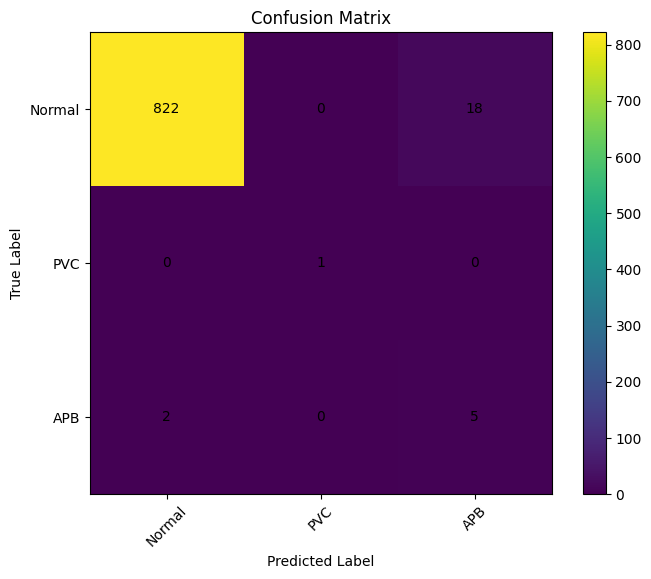

In [ ]:
class_names = [
    'Normal',
    'PVC',
    'APB'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

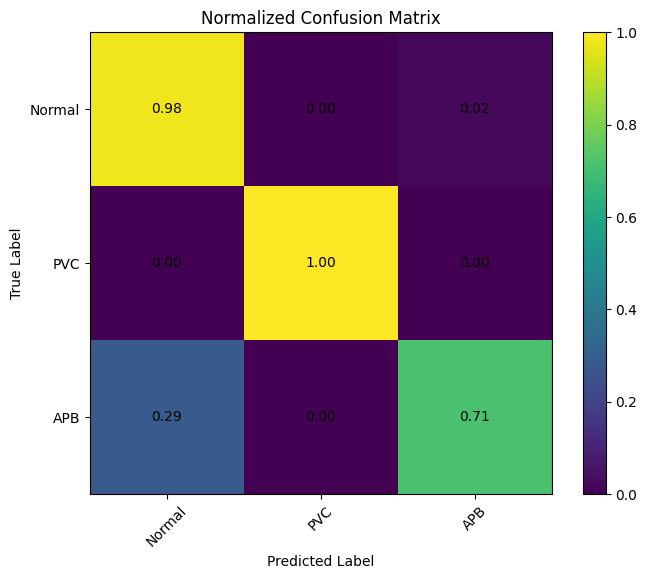

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

plt.imshow(cm_normalized)

plt.title("Normalized Confusion Matrix")

plt.colorbar()

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.show()

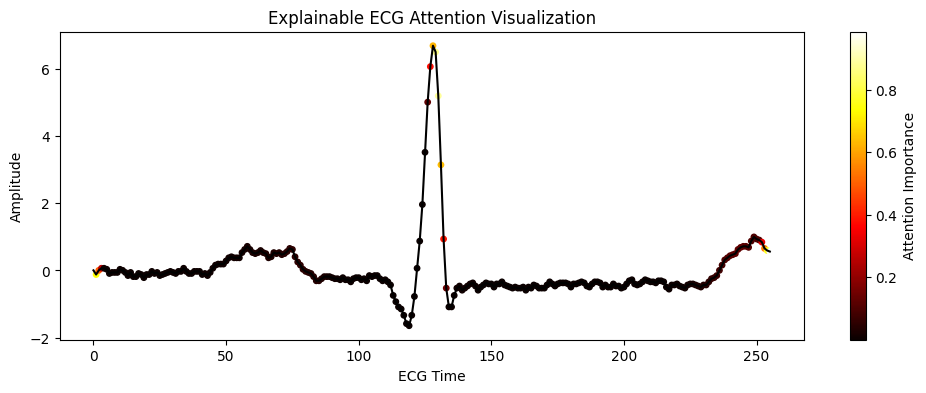

In [ ]:
# Take average attention across heads
attention_map = attention[0].mean(axis=0).cpu().detach().numpy()

# Normalize attention
attention_map = attention_map / attention_map.max()

# Original ECG
sample_signal = X_test[5]

# Resize attention to ECG length
attention_resized = np.interp(
    np.linspace(0, len(attention_map)-1, len(sample_signal)),
    np.arange(len(attention_map)),
    attention_map
)

plt.figure(figsize=(12,4))

plt.plot(sample_signal, color='black', linewidth=1.5)

# Overlay attention
plt.scatter(
    np.arange(len(sample_signal)),
    sample_signal,
    c=attention_resized,
    cmap='hot',
    s=15
)

plt.colorbar(label='Attention Importance')

plt.title("Explainable ECG Attention Visualization")

plt.xlabel("ECG Time")

plt.ylabel("Amplitude")

plt.show()